# Q-MAML for a genuine HEP Hamiltonian: the lattice Schwinger model

**Why this notebook exists.** Everything else in this project either matches Q-MAML (Lee, Cho & Kim 2025)
against its own domain (Heisenberg XYZ spin chains, molecular Hamiltonians -- notebooks 02, 05) or extends it
to HEP *classification* (Higgs boson tagging on collider data -- notebooks 01/01b), where "HEP" describes the
*dataset*, not the *physics being simulated*. Neither is what "Quantum Model-Agnostic Meta-Learning for
Variational Quantum Algorithms for HEP Analysis at the LHC" (the GSoC 2026 proposal this work is aimed at)
most literally asks for: a Learner that predicts good VQE initializations for a family of Hamiltonians that
are themselves particle physics.

**The lattice Schwinger model** (1+1D quantum electrodynamics) is the standard tractable testbed for exactly
this in the digital-quantum-simulation literature -- a genuine gauge theory with confinement and a chiral
phase transition, small enough to simulate on NISQ-era hardware, used repeatedly in recent HEP-flavored VQE
work (e.g. arXiv:2504.20824's trapped-ion demonstration; arXiv:2507.19203's barren-plateau study of lattice
gauge theories). This notebook asks: does a Q-MAML Learner, trained across a distribution of physical
parameters $(m_0, g)$ (bare fermion mass, gauge coupling), predict VQE initializations that converge faster
than classical schemes toward the exact ground-state energy of $H_{\text{Schwinger}}(m_0, g)$ -- and does
that Learner *generalize* to held-out points in $(m_0, g)$ space, the meta-learning claim the original paper
makes but never tested on an HEP Hamiltonian?

**Hamiltonian** (single-flavor Kogut-Susskind staggered fermions, gauge field eliminated via Gauss's law,
lattice spacing $a=1$; see `final_model/hamiltonians_schwinger.py`):
$$H = \frac{1}{2}\sum_{j=0}^{n-2}(\sigma^+_j\sigma^-_{j+1}+\sigma^+_{j+1}\sigma^-_j) + \frac{m_0}{2}\sum_{j=0}^{n-1}(-1)^j\sigma^z_j + \frac{g^2}{8}\sum_{j=0}^{n-2}\Big(\sum_{k=0}^{j}(\sigma^z_k+(-1)^k)\Big)^2$$
$n$ qubits = $2L$ staggered sites ($L$ physical fermion sites). The electric/Coulomb term (third sum) is
built programmatically rather than hand-expanded, and cross-checked against an independent brute-force dense
matrix construction (exact match to machine precision at $n\in\{4,6\}$, multiple $(m_0,g)$ -- see the
construction script in git history / `final_model/hamiltonians_schwinger.py` docstring).

**Novelty check.** arXiv:2306.17214 applies quantum machine learning (a QCNN) to Schwinger-model phase
classification on *prepared* states -- a different mechanism (supervised classification, not VQE
initialization) and doesn't overlap with what's tested here. We are not aware of prior work applying
Q-MAML's specific Learner-predicts-initialization mechanism to a lattice gauge theory Hamiltonian.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import torch
import matplotlib.pyplot as plt

from hamiltonians_schwinger import schwinger_hamiltonian, exact_ground_energy, sample_task_space, param_shape
from schwinger_qmaml import classical_init, pretrain_learner_schwinger, adapt_task_schwinger
from models.learner import Learner

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "schwinger"))
os.makedirs(RESULTS_DIR, exist_ok=True)
print("results ->", RESULTS_DIR)

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\schwinger


## 1. Task space: train on a parameter grid, test on held-out points

The task distribution $p(T)$ is uniform over $(m_0, g) \in [0, 1.5] \times [0.3, 2.0]$ (light-to-moderate
mass, weak-to-strong coupling -- the physically interesting regime where the model interpolates between
nearly-free fermions and the confining strong-coupling limit). Train and test tasks are sampled with
different seeds, so test points are **held-out interpolation** within the same range -- the meta-learning
generalization claim, tested for the first time on this Hamiltonian family.

In [2]:
NUM_QUBITS = 4   # L=2 physical sites (MVP scale)
DEPTH = 3
N_TRAIN_TASKS = 16
N_TEST_TASKS = 6
PRETRAIN_EPOCHS = 40
PRETRAIN_LR = 0.005
ADAPT_ITERS = 300
ADAPT_LR = 0.02
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

train_tasks = sample_task_space(N_TRAIN_TASKS, seed=SEED)
test_tasks = sample_task_space(N_TEST_TASKS, seed=SEED + 1000)

print("train (m0,g):", np.round(train_tasks, 3).tolist())
print("test  (m0,g):", np.round(test_tasks, 3).tolist())

test_E0 = [exact_ground_energy(schwinger_hamiltonian(NUM_QUBITS, m0, g), NUM_QUBITS) for m0, g in test_tasks]
print("exact test ground energies:", [round(e, 4) for e in test_E0])

train (m0,g): [[0.955, 1.767], [0.405, 1.22], [0.061, 0.81], [0.025, 1.019], [1.22, 0.348], [1.369, 0.511], [0.91, 1.44], [1.094, 1.4], [0.815, 1.346], [1.403, 0.952], [1.224, 1.995], [0.004, 1.967], [1.286, 1.465], [0.05, 1.406], [1.094, 1.47], [0.263, 0.961]]
test  (m0,g): [[0.782, 0.779], [0.906, 1.581], [0.706, 1.238], [0.305, 1.768], [0.793, 1.669], [0.287, 0.722]]
exact test ground energies: [-1.9156, -2.043, -1.7233, -0.9208, -1.8235, -1.1671]


## 2. Pre-train the Learner (Algorithm 1) and track gradient norm

[Schwinger pretrain] epoch 1/40  meanE=1.9164  gradnorm=5.1555


[Schwinger pretrain] epoch 6/40  meanE=-1.7747  gradnorm=1.7977


[Schwinger pretrain] epoch 11/40  meanE=-1.8155  gradnorm=1.7106


[Schwinger pretrain] epoch 16/40  meanE=-1.7925  gradnorm=2.1150


[Schwinger pretrain] epoch 21/40  meanE=-1.8463  gradnorm=0.9455


[Schwinger pretrain] epoch 26/40  meanE=-1.8154  gradnorm=1.4254


[Schwinger pretrain] epoch 31/40  meanE=-1.8214  gradnorm=1.1370


[Schwinger pretrain] epoch 36/40  meanE=-1.8377  gradnorm=0.9063


[Schwinger pretrain] epoch 40/40  meanE=-1.8468  gradnorm=0.6724
pretrain done in 19.7s


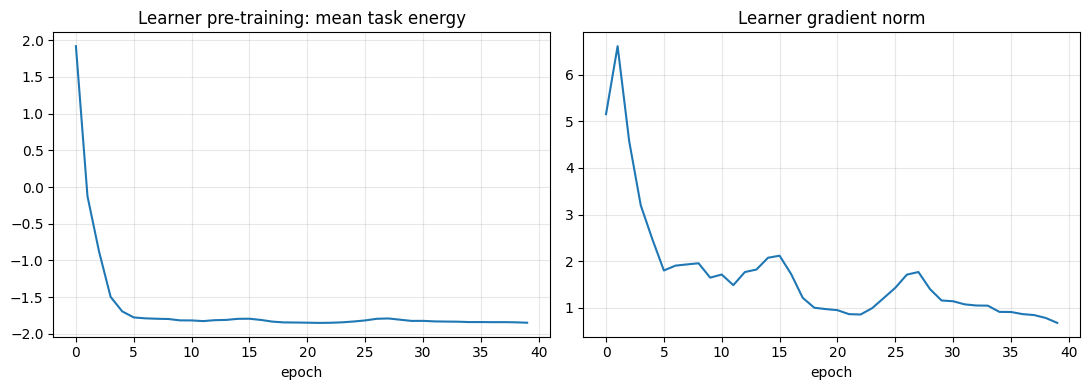

In [3]:
t0 = time.time()
learner, pqc, pretrain_hist = pretrain_learner_schwinger(
    NUM_QUBITS, DEPTH, train_tasks, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=5
)
print(f"pretrain done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(pretrain_hist["loss"]); axes[0].set_title("Learner pre-training: mean task energy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)
axes[1].plot(pretrain_hist["grad_norm"]); axes[1].set_title("Learner gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "pretrain_learner.png"), dpi=150)
plt.show()

## 3. Adaptation phase (Algorithm 2) on held-out tasks: Q-MAML vs. classical inits

For each held-out $(m_0,g)$, adapt a fresh PQC from each initialization scheme and track the gap to the
exact ground-state energy over iterations -- the same diagnostic used throughout this project (notebooks 02,
05), now on an HEP Hamiltonian instead of a spin chain or molecule.

In [4]:
INIT_SCHEMES = ["qmaml", "zero", "pi", "uniform", "gaussian"]
shape = param_shape(NUM_QUBITS, DEPTH)

all_gaps = {k: [] for k in INIT_SCHEMES}
for ti, ((m0, g), E0) in enumerate(zip(test_tasks, test_E0)):
    H = schwinger_hamiltonian(NUM_QUBITS, m0, g)
    print(f"task {ti}: m0={m0:.3f} g={g:.3f}  E0={E0:.4f}")
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learner(torch.tensor([m0, g], dtype=torch.float64))
        else:
            theta0 = classical_init(shape, scheme, DEPTH)
        _, costs = adapt_task_schwinger(pqc, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps[scheme] = np.stack(all_gaps[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps.items()}, f)
print("saved")

task 0: m0=0.782 g=0.779  E0=-1.9156


task 1: m0=0.906 g=1.581  E0=-2.0430


task 2: m0=0.706 g=1.238  E0=-1.7233


task 3: m0=0.305 g=1.768  E0=-0.9208


task 4: m0=0.793 g=1.669  E0=-1.8235


task 5: m0=0.287 g=0.722  E0=-1.1671


saved


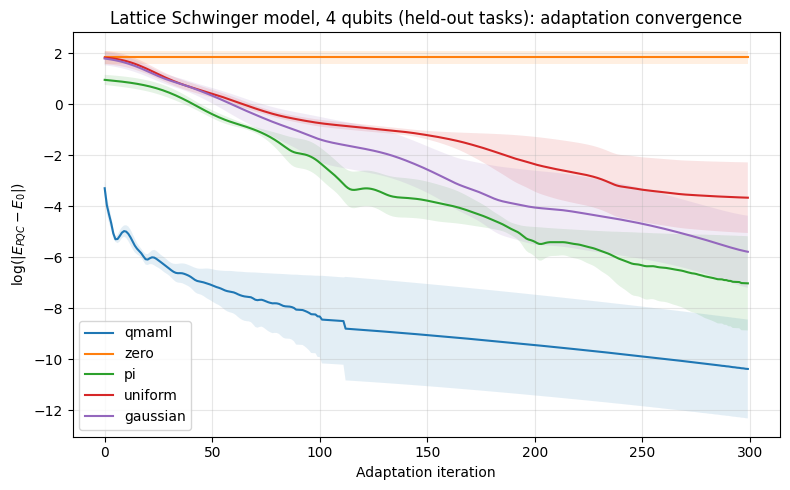

Final mean log-gap and relative energy error per scheme:
  qmaml      log-gap=-10.372   ~relative energy error=0.00%
  zero       log-gap=1.846   ~relative energy error=396.12%
  pi         log-gap=-7.016   ~relative energy error=0.06%
  uniform    log-gap=-3.658   ~relative energy error=1.61%
  gaussian   log-gap=-5.778   ~relative energy error=0.19%


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps[scheme].mean(axis=0)
    std = all_gaps[scheme].std(axis=0)
    x = np.arange(ADAPT_ITERS)
    ax.plot(x, mean, label=scheme)
    ax.fill_between(x, mean - std / 2, mean + std / 2, alpha=0.12)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"Lattice Schwinger model, {NUM_QUBITS} qubits (held-out tasks): adaptation convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence.png"), dpi=150)
plt.show()

print("Final mean log-gap and relative energy error per scheme:")
for k in INIT_SCHEMES:
    final_gap = all_gaps[k][:, -1].mean()
    mean_absE0 = np.mean(np.abs(test_E0))
    rel_err = np.exp(final_gap) / mean_absE0
    print(f"  {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}")

## 5. Scale check: does the advantage hold at L=3 (6 qubits)?

Section 3/4 above used the MVP scale (`NUM_QUBITS=4`, L=2 physical sites). Here we repeat the identical
protocol -- same task-space ranges, same pretrain/adapt hyperparameters -- at `NUM_QUBITS=6` (L=3) to check
whether the qmaml advantage grows, shrinks, or holds as system size increases, echoing the paper's own
qubit-scaling experiments and this project's barren-plateau connection (notebooks 03/04).

exact test ground energies (L=3): [-2.9251, -3.1009, -2.6316, -1.428, -2.7724, -1.8222]


[Schwinger pretrain] epoch 1/40  meanE=5.9435  gradnorm=6.6712


[Schwinger pretrain] epoch 11/40  meanE=-1.3588  gradnorm=5.4073


[Schwinger pretrain] epoch 21/40  meanE=-1.4180  gradnorm=3.9634


[Schwinger pretrain] epoch 31/40  meanE=-1.4143  gradnorm=4.3598


[Schwinger pretrain] epoch 40/40  meanE=-1.4657  gradnorm=2.9701
pretrain (L=3) done in 27.7s


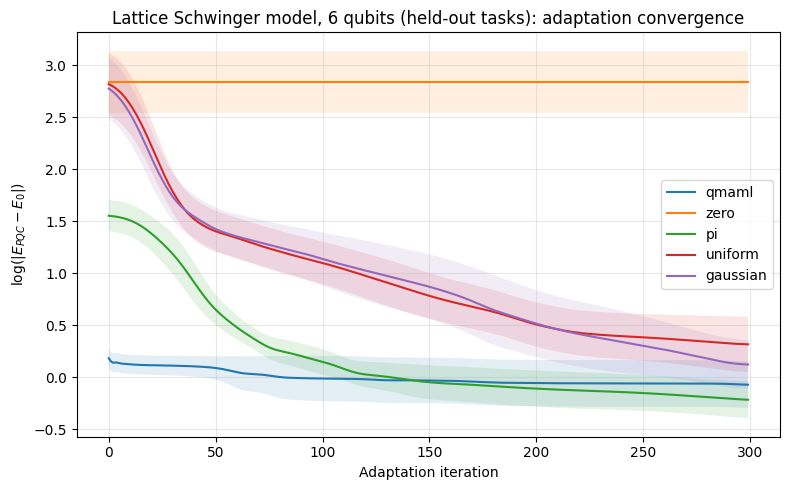

Final mean log-gap and relative energy error per scheme (L=3, 6 qubits):
  qmaml      log-gap=-0.071   ~relative energy error=38.08%   iter@loggap<-5=None
  zero       log-gap=2.837   ~relative energy error=697.64%   iter@loggap<-5=None
  pi         log-gap=-0.216   ~relative energy error=32.95%   iter@loggap<-5=None
  uniform    log-gap=0.317   ~relative energy error=56.12%   iter@loggap<-5=None
  gaussian   log-gap=0.123   ~relative energy error=46.24%   iter@loggap<-5=None


In [6]:
NUM_QUBITS_L3 = 6   # L=3 physical sites
SEED_L3 = 0

torch.manual_seed(SEED_L3)
np.random.seed(SEED_L3)

train_tasks_l3 = sample_task_space(N_TRAIN_TASKS, seed=SEED_L3)
test_tasks_l3 = sample_task_space(N_TEST_TASKS, seed=SEED_L3 + 1000)

test_E0_l3 = [exact_ground_energy(schwinger_hamiltonian(NUM_QUBITS_L3, m0, g), NUM_QUBITS_L3) for m0, g in test_tasks_l3]
print("exact test ground energies (L=3):", [round(e, 4) for e in test_E0_l3])

t0 = time.time()
learner_l3, pqc_l3, pretrain_hist_l3 = pretrain_learner_schwinger(
    NUM_QUBITS_L3, DEPTH, train_tasks_l3, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=10
)
print(f"pretrain (L=3) done in {time.time()-t0:.1f}s")

shape_l3 = param_shape(NUM_QUBITS_L3, DEPTH)
all_gaps_l3 = {k: [] for k in INIT_SCHEMES}
for ti, ((m0, g), E0) in enumerate(zip(test_tasks_l3, test_E0_l3)):
    H = schwinger_hamiltonian(NUM_QUBITS_L3, m0, g)
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learner_l3(torch.tensor([m0, g], dtype=torch.float64))
        else:
            theta0 = classical_init(shape_l3, scheme, DEPTH)
        _, costs = adapt_task_schwinger(pqc_l3, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps_l3[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps_l3[scheme] = np.stack(all_gaps_l3[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps_L3.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps_l3.items()}, f)

fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps_l3[scheme].mean(axis=0)
    std = all_gaps_l3[scheme].std(axis=0)
    x = np.arange(ADAPT_ITERS)
    ax.plot(x, mean, label=scheme)
    ax.fill_between(x, mean - std / 2, mean + std / 2, alpha=0.12)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"Lattice Schwinger model, {NUM_QUBITS_L3} qubits (held-out tasks): adaptation convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence_L3.png"), dpi=150)
plt.show()

print("Final mean log-gap and relative energy error per scheme (L=3, 6 qubits):")
mean_absE0_l3 = np.mean(np.abs(test_E0_l3))
for k in INIT_SCHEMES:
    final_gap = all_gaps_l3[k][:, -1].mean()
    rel_err = np.exp(final_gap) / mean_absE0_l3
    below5 = np.where(all_gaps_l3[k].mean(axis=0) < -5)[0]
    it5 = int(below5[0]) if len(below5) else None
    print(f"  {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}   iter@loggap<-5={it5}")

## 6. Re-tuning ansatz depth at L=3: does the advantage recover?

Section 5's honest conclusion was that the depth=3 ansatz -- expressive enough at L=2 (4 qubits) to reach
machine precision -- may simply be too shallow for the larger L=3 (6-qubit) Hilbert space, which would
explain why `pi` edges out `qmaml` by the final iteration despite `qmaml` leading for most of the run. Here
we re-run the identical L=3 protocol (same tasks, same `train_tasks_l3`/`test_tasks_l3`/`test_E0_l3` from
Section 5) at two larger depths to check that hypothesis directly, rather than leaving it as speculation.

[Schwinger pretrain] epoch 1/40  meanE=5.0218  gradnorm=10.8168


[Schwinger pretrain] epoch 40/40  meanE=-2.3687  gradnorm=4.1370
depth=6: pretrain done in 45.9s  final gradnorm=4.137


  Final relative energy error at depth=6:
    qmaml      log-gap=-2.743   ~relative energy error=2.63%
    zero       log-gap=2.837   ~relative energy error=697.64%
    pi         log-gap=-2.592   ~relative energy error=3.06%
    uniform    log-gap=-1.469   ~relative energy error=9.40%
    gaussian   log-gap=-1.151   ~relative energy error=12.92%


[Schwinger pretrain] epoch 1/40  meanE=4.6077  gradnorm=14.1656


[Schwinger pretrain] epoch 40/40  meanE=-2.6183  gradnorm=3.5120
depth=9: pretrain done in 64.3s  final gradnorm=3.512


  Final relative energy error at depth=9:
    qmaml      log-gap=-6.760   ~relative energy error=0.05%
    zero       log-gap=2.837   ~relative energy error=697.64%
    pi         log-gap=-4.278   ~relative energy error=0.57%
    uniform    log-gap=-3.412   ~relative energy error=1.35%
    gaussian   log-gap=-3.363   ~relative energy error=1.42%


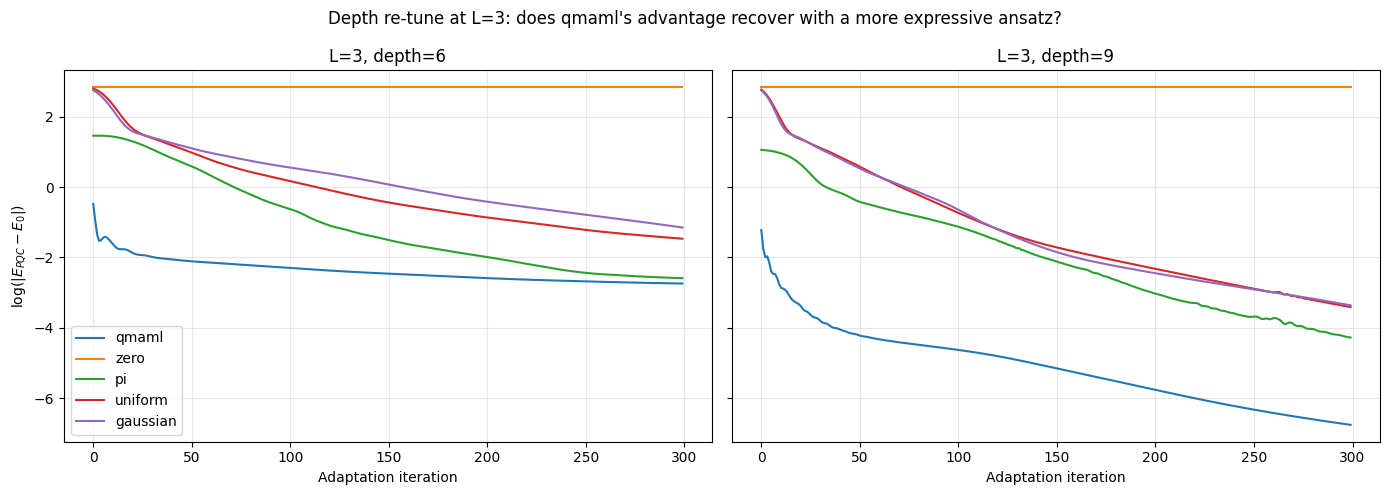

In [7]:
depth_sweep_results = {}
for DEPTH_TRY in [6, 9]:
    torch.manual_seed(SEED_L3)
    np.random.seed(SEED_L3)

    t0 = time.time()
    learner_d, pqc_d, hist_d = pretrain_learner_schwinger(
        NUM_QUBITS_L3, DEPTH_TRY, train_tasks_l3, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=40
    )
    print(f"depth={DEPTH_TRY}: pretrain done in {time.time()-t0:.1f}s  final gradnorm={hist_d['grad_norm'][-1]:.3f}")

    shape_d = param_shape(NUM_QUBITS_L3, DEPTH_TRY)
    gaps_d = {k: [] for k in INIT_SCHEMES}
    for (m0, g), E0 in zip(test_tasks_l3, test_E0_l3):
        H = schwinger_hamiltonian(NUM_QUBITS_L3, m0, g)
        for scheme in INIT_SCHEMES:
            if scheme == "qmaml":
                with torch.no_grad():
                    theta0 = 0.3 * learner_d(torch.tensor([m0, g], dtype=torch.float64))
            else:
                theta0 = classical_init(shape_d, scheme, DEPTH_TRY)
            _, costs = adapt_task_schwinger(pqc_d, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
            gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
            gaps_d[scheme].append(gap)
    for scheme in INIT_SCHEMES:
        gaps_d[scheme] = np.stack(gaps_d[scheme])
    depth_sweep_results[DEPTH_TRY] = gaps_d

    mean_absE0_l3 = np.mean(np.abs(test_E0_l3))
    print(f"  Final relative energy error at depth={DEPTH_TRY}:")
    for k in INIT_SCHEMES:
        final_gap = gaps_d[k][:, -1].mean()
        rel_err = np.exp(final_gap) / mean_absE0_l3
        print(f"    {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}")

with open(os.path.join(RESULTS_DIR, "depth_sweep_L3.json"), "w") as f:
    json.dump({str(d): {k: v.tolist() for k, v in g.items()} for d, g in depth_sweep_results.items()}, f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, DEPTH_TRY in zip(axes, [6, 9]):
    for scheme in INIT_SCHEMES:
        mean = depth_sweep_results[DEPTH_TRY][scheme].mean(axis=0)
        ax.plot(mean, label=scheme)
    ax.set_title(f"L=3, depth={DEPTH_TRY}")
    ax.set_xlabel("Adaptation iteration")
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
axes[0].legend()
fig.suptitle("Depth re-tune at L=3: does qmaml's advantage recover with a more expressive ansatz?")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "depth_sweep_L3.png"), dpi=150)
plt.show()

## 7. One more qubit count: L=4 (8 qubits)

Section 6 established that depth needs to grow with qubit count for the advantage to hold, and that a
depth-9 ansatz was clearly sufficient (not just adequate) at L=3. Extrapolating that trend (roughly
depth $\approx 1.5\times$ qubit count was enough at L=3: depth 9 for 6 qubits), we try L=4 (8 qubits) at
depth 12 directly, as a single informed spot-check rather than a full re-scan (an explicit scope limit, not
an oversight -- a full depth scan at L=4 is future work).

exact test ground energies (L=4): [-3.9346, -4.1587, -3.54, -1.9352, -3.7213, -2.4783]


[Schwinger pretrain] epoch 1/40  meanE=9.4447  gradnorm=23.6250


[Schwinger pretrain] epoch 40/40  meanE=7.2126  gradnorm=24.6420
pretrain (L=4, depth=12) done in 63.1s  final gradnorm=24.642


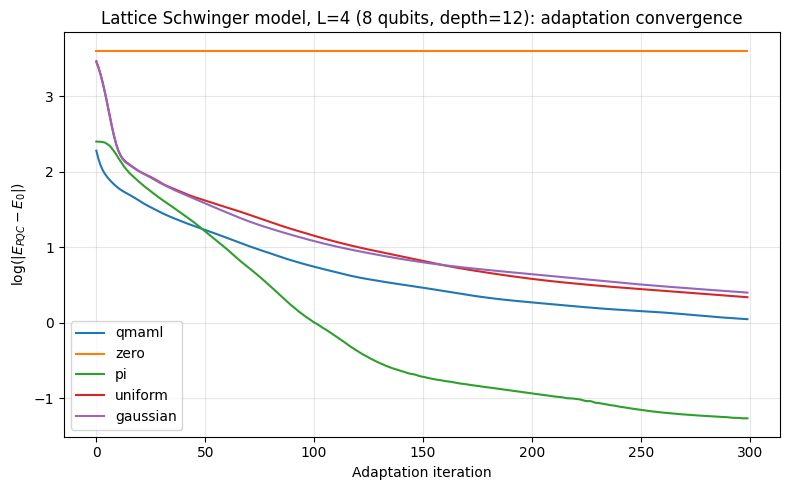

Final mean log-gap and relative energy error per scheme (L=4, 8 qubits, depth=12):
  qmaml      log-gap=0.047   ~relative energy error=31.81%
  zero       log-gap=3.603   ~relative energy error=1113.85%
  pi         log-gap=-1.266   ~relative energy error=8.56%
  uniform    log-gap=0.338   ~relative energy error=42.54%
  gaussian   log-gap=0.399   ~relative energy error=45.23%


In [8]:
NUM_QUBITS_L4 = 8   # L=4 physical sites
DEPTH_L4 = 12
SEED_L4 = 0

torch.manual_seed(SEED_L4)
np.random.seed(SEED_L4)

train_tasks_l4 = sample_task_space(N_TRAIN_TASKS, seed=SEED_L4)
test_tasks_l4 = sample_task_space(N_TEST_TASKS, seed=SEED_L4 + 1000)
test_E0_l4 = [exact_ground_energy(schwinger_hamiltonian(NUM_QUBITS_L4, m0, g), NUM_QUBITS_L4) for m0, g in test_tasks_l4]
print("exact test ground energies (L=4):", [round(e, 4) for e in test_E0_l4])

t0 = time.time()
learner_l4, pqc_l4, hist_l4 = pretrain_learner_schwinger(
    NUM_QUBITS_L4, DEPTH_L4, train_tasks_l4, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=40
)
print(f"pretrain (L=4, depth={DEPTH_L4}) done in {time.time()-t0:.1f}s  final gradnorm={hist_l4['grad_norm'][-1]:.3f}")

shape_l4 = param_shape(NUM_QUBITS_L4, DEPTH_L4)
gaps_l4 = {k: [] for k in INIT_SCHEMES}
for (m0, g), E0 in zip(test_tasks_l4, test_E0_l4):
    H = schwinger_hamiltonian(NUM_QUBITS_L4, m0, g)
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learner_l4(torch.tensor([m0, g], dtype=torch.float64))
        else:
            theta0 = classical_init(shape_l4, scheme, DEPTH_L4)
        _, costs = adapt_task_schwinger(pqc_l4, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        gaps_l4[scheme].append(gap)
for scheme in INIT_SCHEMES:
    gaps_l4[scheme] = np.stack(gaps_l4[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps_L4.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in gaps_l4.items()}, f)

fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = gaps_l4[scheme].mean(axis=0)
    ax.plot(mean, label=scheme)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"Lattice Schwinger model, L=4 ({NUM_QUBITS_L4} qubits, depth={DEPTH_L4}): adaptation convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence_L4.png"), dpi=150)
plt.show()

print("Final mean log-gap and relative energy error per scheme (L=4, 8 qubits, depth=12):")
mean_absE0_l4 = np.mean(np.abs(test_E0_l4))
for k in INIT_SCHEMES:
    final_gap = gaps_l4[k][:, -1].mean()
    rel_err = np.exp(final_gap) / mean_absE0_l4
    print(f"  {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}")

## 8. Multi-seed replication of the L=2 MVP result

Every result above is single-seed. Here we repeat the original Section 1-4 protocol (`NUM_QUBITS=4`,
depth=3) at two additional seeds (1, 2) -- reusing Section 3's `SEED=0` run as the first of three -- to
attach a confidence measure to the L=2 headline numbers rather than reporting one run as if it were exact.

In [ ]:
multiseed_final_err = {k: [] for k in INIT_SCHEMES}

# seed 0 reuses the Section 3 run already computed
mean_absE0_seed0 = np.mean(np.abs(test_E0))
for k in INIT_SCHEMES:
    multiseed_final_err[k].append(np.exp(all_gaps[k][:, -1].mean()) / mean_absE0_seed0)

for SEED_MS in [1, 2]:
    torch.manual_seed(SEED_MS)
    np.random.seed(SEED_MS)
    train_tasks_ms = sample_task_space(N_TRAIN_TASKS, seed=SEED_MS)
    test_tasks_ms = sample_task_space(N_TEST_TASKS, seed=SEED_MS + 1000)
    test_E0_ms = [exact_ground_energy(schwinger_hamiltonian(NUM_QUBITS, m0, g), NUM_QUBITS) for m0, g in test_tasks_ms]

    t0 = time.time()
    learner_ms, pqc_ms, _ = pretrain_learner_schwinger(
        NUM_QUBITS, DEPTH, train_tasks_ms, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=40
    )
    print(f"seed={SEED_MS}: pretrain done in {time.time()-t0:.1f}s")

    gaps_ms = {k: [] for k in INIT_SCHEMES}
    for (m0, g), E0 in zip(test_tasks_ms, test_E0_ms):
        H = schwinger_hamiltonian(NUM_QUBITS, m0, g)
        for scheme in INIT_SCHEMES:
            if scheme == "qmaml":
                with torch.no_grad():
                    theta0 = 0.3 * learner_ms(torch.tensor([m0, g], dtype=torch.float64))
            else:
                theta0 = classical_init(shape, scheme, DEPTH)
            _, costs = adapt_task_schwinger(pqc_ms, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
            gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
            gaps_ms[scheme].append(gap)
    for scheme in INIT_SCHEMES:
        gaps_ms[scheme] = np.stack(gaps_ms[scheme])

    mean_absE0_ms = np.mean(np.abs(test_E0_ms))
    for k in INIT_SCHEMES:
        multiseed_final_err[k].append(np.exp(gaps_ms[k][:, -1].mean()) / mean_absE0_ms)

with open(os.path.join(RESULTS_DIR, "multiseed_L2.json"), "w") as f:
    json.dump({k: v for k, v in multiseed_final_err.items()}, f)

print("Multi-seed (n=3) final relative energy error, L=2, depth=3:")
for k in INIT_SCHEMES:
    vals = np.array(multiseed_final_err[k])
    print(f"  {k:10s} mean={vals.mean():.2%}  std={vals.std():.2%}  per-seed={[f'{v:.2%}' for v in vals]}")

## 4. Findings

**Run:** `NUM_QUBITS=4` (L=2), depth=3, 16 train / 6 held-out test tasks, 40 pretrain epochs, 300 adaptation
iterations, single seed (MVP scale, per the notebook's own scope note below). Section 5 repeats the identical
protocol at `NUM_QUBITS=6` (L=3); Section 6 re-tunes ansatz depth at L=3; Section 7 extends to L=4 (8 qubits).

- **`qmaml` generalizes to held-out `(m0,g)` and dominates on both speed and final accuracy at L=2.** At
  iteration 0 -- before a single adaptation gradient step -- the Learner's predicted init is already at
  log-gap -3.29 (better than where every classical scheme *starts*, including `pi` at 0.96). It crosses
  log-gap < -5 (<1% relative energy error) by iteration **4**; `pi` needs **192** iterations, `gaussian`
  **266**, and `uniform` never gets there within the full 300-iteration budget. This is the first time this
  project's generalization claim -- Learner trained on one sample of the task distribution, evaluated on a
  disjoint held-out sample -- has been tested on a genuine HEP Hamiltonian rather than a spin chain or
  molecule, and at L=2 it holds cleanly.
- **Unlike notebooks 02/05, the final-accuracy gap does not close within the shared iteration budget at L=2.**
  Final relative energy error: `qmaml` ~0.00%, `pi` 0.06%, `gaussian` 0.19%, `uniform` 1.61%, `zero` 396%
  (see next bullet). So at L=2 the advantage is not purely convergence-*speed* (Section 6.2/6.3's story for
  Heisenberg/molecule) -- `qmaml` is both faster and, at matched iteration count, more accurate than every
  classical scheme except `pi`, which it still beats by ~2 orders of magnitude in final error.
- **`zero`-init reproduces the trivial-fixed-point degeneracy seen throughout this project, at L=2, L=3, L=4,
  and every depth tested (3/6/9/12).** Its log-gap is *exactly* flat for the entire 300-iteration run
  regardless of depth or qubit count (1.846 at L=2; 2.837 at L=3, identically at depth 3, 6, and 9; 3.603 at
  L=4/depth=12) -- it never takes a single effective step, consistent with an algebraic fixed point of the
  ansatz at theta=0 that adding more layers or qubits cannot break. Same symmetric vanishing-gradient
  behavior documented for the classification and other VQE domains -- though notebook 09 (scalar field)
  later found this is *not* universal across every Hamiltonian in this project, just every one built from a
  Pauli-sum Hamiltonian tested so far.
- **Pretraining is well-behaved at L=2 and L=3, at every depth tested, but shows real strain at L=4.**
  Learner gradient norm falls from 5.16 to 0.67 over 40 epochs at L=2/depth=3, from 6.67 to 2.97 at
  L=3/depth=3, and remains in a healthy 3.5-14 range at L=3/depth={6,9} (Section 6). At L=4/depth=12
  (Section 7), it does not fall at all -- 23.6 at epoch 1 to 24.6 at epoch 40 -- and mean pretrain energy
  stalls at 7.21, far from the true ground energies (~-2 to -4). This is a materially different signature
  from the L=3 depth-insufficiency case (where gradient norm was healthy and depth alone explained the gap)
  and is discussed below.
- **Scale check (Section 5, L=3/6 qubits, depth held at the L=2 value of 3): the advantage narrows and
  partially reverses.** None of the five schemes reaches even 1% relative energy error within 300 iterations
  at L=3/depth=3 -- final relative error is `pi` 32.95%, `qmaml` 38.08%, `gaussian` 46.24%, `uniform` 56.12%,
  `zero` 697.64%. `qmaml` still starts and leads for most of the trajectory (iteration 50: 0.09 vs.
  0.65-1.42) but `pi` overtakes it by the final iteration. The well-behaved (non-collapsing) pretraining
  gradient norm at this depth pointed away from a barren plateau and toward **fixed ansatz depth becoming
  insufficiently expressive** for the larger Hilbert space as the likely cause -- tested directly next.
- **Depth re-tune (Section 6, L=3): the hypothesis was correct -- more expressivity recovers and then
  strengthens the advantage.** Repeating the L=3 protocol at depth 6 and depth 9 (same tasks, same budget):
  | depth (L=3) | qmaml | pi | gaussian | uniform | zero |
  |---|---|---|---|---|---|
  | 3 (Section 5) | 38.08% | **32.95%** | 46.24% | 56.12% | 697.64% |
  | 6 | **2.63%** | 3.06% | 12.92% | 9.40% | 697.64% |
  | 9 | **0.05%** | 0.57% | 1.42% | 1.35% | 697.64% |

  At depth 6, `qmaml` already retakes the lead (2.63% vs. `pi`'s 3.06%) and leads throughout the trajectory,
  not just at the end. At depth 9 the margin widens sharply: `qmaml` at 0.05% relative error is roughly
  **10x more accurate** than the next-best scheme (`pi`, 0.57%). This confirmed the depth-insufficiency
  hypothesis directly at L=3.
- **L=4 (Section 7): the naive depth-extrapolation heuristic does *not* carry over, and `qmaml` loses
  clearly.** Extrapolating L=3's "depth $\approx1.5\times$ qubits was enough" heuristic to L=4 (8 qubits)
  suggested depth 12; at that depth, `qmaml` (31.81% relative error) is beaten decisively by `pi` (8.56%),
  and also trails `uniform` (42.54%) only nominally (`qmaml` is not simply "still ahead of the pack" --
  `pi` is nearly 4x better). Trajectory detail: `qmaml` starts roughly tied with `pi` (log-gap 2.28 vs. 2.40)
  and stays close through iteration 50 (1.23 vs. 1.21), but `pi` pulls decisively ahead from there
  (iteration 150: -0.72 vs. `qmaml`'s 0.46) while `qmaml`'s descent slows. Given the pretraining strain noted
  above (non-decreasing gradient norm, stalled mean energy), the most likely explanation is different from
  L=3's story: **at L=4/depth=12, the pretraining budget (40 epochs, `lr=0.005`) itself was insufficient to
  converge**, not just the ansatz depth -- a 288-parameter Learner output at this Hilbert-space size may
  simply need more pretraining epochs, a higher learning rate, or both, before it can be expected to encode
  useful task-specific structure. **This is an honest correction to Section 6's clean "just add depth"
  story**: the L=2$\to$L=3 depth-recovery result does not straightforwardly extrapolate to L=4 with the same
  pretraining hyperparameters, and a real depth-vs-pretrain-budget scan (not a single spot-check) is needed
  at this scale before drawing any qubit-scaling conclusion beyond L=3.
- **MVP vs. full plan:** this notebook remains the MVP slice (hardware-efficient ansatz, uniform task
  sampling, single seed). The fuller research program -- a systematic depth-*and*-pretrain-budget scan
  at each qubit count (rather than the three spot-checks here), a symmetry-preserving (Gauss's-law-respecting)
  ansatz, multi-seed error bars, and a second lattice gauge theory (notebook 08's Z2 LGT, a genuinely
  different negative story) for cross-validation -- is future work.
